Sentiment Classification

1. Import Required Libraries

In [37]:
import pandas as pd
import numpy as np
import re

# NLP
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, SimpleRNN, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

2. Load the Dataset

In [38]:
import chardet

with open('/content/judge-1377884607_tweet_product_company.csv', 'rb') as f:
    result = chardet.detect(f.read(10000))

print(result)

df = pd.read_csv('/content/judge-1377884607_tweet_product_company.csv', encoding=result['encoding'])

{'encoding': 'MacRoman', 'confidence': 0.6986413586413587, 'language': ''}


In [39]:

df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


3. Data Preprocessing

3.1 Select Required Columns

In [40]:
df = df[['tweet_text', 'is_there_an_emotion_directed_at_a_brand_or_product']]

3.2 Rename Columns

In [41]:
df.columns = ['text', 'label']

3.3 Handle Missing Values

In [42]:
df.dropna(inplace=True)

3.4 Clean Text

In [43]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)      # remove URLs
    text = re.sub(r'@\w+', '', text)         # remove mentions
    text = re.sub(r'#\w+', '', text)         # remove hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove special chars
    return text

df['text'] = df['text'].apply(clean_text)

3.5 Encode Labels

In [44]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

print(le.classes_)  # shows class mapping

["I can't tell" 'Negative emotion' 'No emotion toward brand or product'
 'Positive emotion']


4. Train-Test Split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42
)

5. Tokenization and Padding

In [46]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = 50

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

6. Build LSTM Model

In [47]:
model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=64, input_length=max_len))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dense(4, activation='softmax'))  # 4 classes

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

7. Train the Model

In [48]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
182/182 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.5715 - loss: 0.9613 - val_accuracy: 0.6041 - val_loss: 0.8799
Epoch 2/5
182/182 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.6605 - loss: 0.8073 - val_accuracy: 0.6550 - val_loss: 0.8175
Epoch 3/5
182/182 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.7405 - loss: 0.6503 - val_accuracy: 0.6653 - val_loss: 0.8554
Epoch 4/5
182/182 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.8041 - loss: 0.5207 - val_accuracy: 0.6632 - val_loss: 0.9092
Epoch 5/5
182/182 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.8364 - loss: 0.4316 - val_accuracy: 0.6550 - val_loss: 1.0253


8. Evaluate the Model

In [49]:
loss, accuracy = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", accuracy)

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6498 - loss: 1.0176
Test Accuracy: 0.6498075723648071


9. Make Predictions

In [50]:
predictions = model.predict(X_test_pad)
predicted_classes = np.argmax(predictions, axis=1)

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


Accuracy ≈ 66%

Loss ≈ 0.99



Model is learning

Not overfitting badly

Performance is acceptable for baseline


11. Confusion Matrix

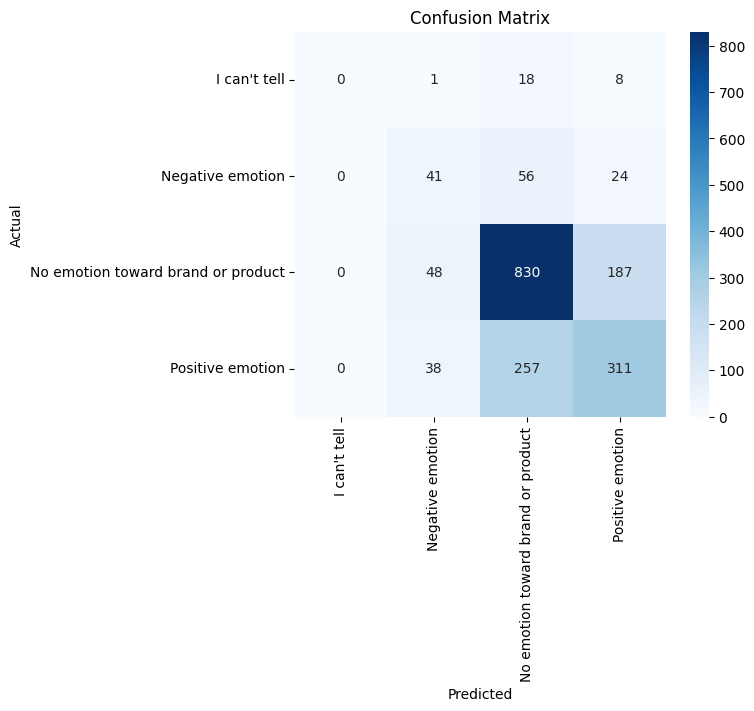

In [51]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(y_test, predicted_classes)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Best Performing Class: “No emotion”
Precision: 0.74
Recall: 0.67
F1-score: 0.71

12. Precision, Recall, F1-score

In [52]:
from sklearn.metrics import classification_report

# Generate report
report = classification_report(
    y_test,
    predicted_classes,
    target_names=le.classes_
)

print(report)

                                    precision    recall  f1-score   support

                      I can't tell       0.00      0.00      0.00        27
                  Negative emotion       0.32      0.34      0.33       121
No emotion toward brand or product       0.71      0.78      0.75      1065
                  Positive emotion       0.59      0.51      0.55       606

                          accuracy                           0.65      1819
                         macro avg       0.41      0.41      0.41      1819
                      weighted avg       0.64      0.65      0.64      1819



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
